# Current version : 9.D (2025-04-29)

In [1]:
from module.misc import sample_name_import

name_dir = "circa-SD"

samples, samples_ids = sample_name_import(name_dir)

print(len(samples))
print(samples)

12
['circa4-IGM-ZT01', 'circa4-IGM-ZT05', 'circa4-IGM-ZT09', 'circa4-IGM-ZT13', 'circa4-IGM-ZT17', 'circa4-IGM-ZT21', 'SD1-ZT01', 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', 'SD1-ZT17', 'SD1-ZT21']


In [ ]:
import pandas as pd

In [ ]:
df_circa2 = pd.read_excel('data/cyc_analysis_nonzero_circa2.xlsx', sheet_name = 'sig_cyl_gene')
df_circa4 = pd.read_excel('data/cyc_analysis_nonzero_circa4.xlsx', sheet_name = 'sig_cyl_gene')

In [ ]:
circa4_gene = set(df_circa4['CycID'])
circa2_gene = set(df_circa2['CycID'])

In [ ]:
common_genes = circa4_gene.intersection(circa2_gene)

In [ ]:
len(common_genes), len(circa4_gene),len(circa2_gene)

In [ ]:
# library
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Use the venn2 function
venn2(subsets = (1449, 846, 560), set_labels = ('IGM', 'Salk'))
plt.show()


### Polar plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample structure: replace this with your real data
# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': ['Arntl', 'Clock', 'Cry1', 'Cry2','Npas2', 'Nr1d1', 'Per2', 'Per3','Rorc',
                            'Arntl','Clock','Cry1','Nr1d1','Per1','Per2','Per3','Rorc'
                            ],
                    'Phase': [1.00, 8.38, 15.31, 12.89, 22.56, 8.96,15.30,13.06,16.54,
                              1.00, 3.15, 16.75, 9.02, 11.92, 16.23, 14.17, 17.06
                            ]
                    })

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

ax.set_yticks(range(1, len(gene_order) + 1))
ax.set_yticklabels(gene_order)
ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left", title='Gene')

plt.tight_layout()
plt.show()

### Cell type spe polar

In [ ]:
import pandas as pd
df = pd.read_excel('data/circa2_cyc_siggene_analysis_celltype.xlsx', sheet_name=None)

In [ ]:
clockgenelist=['Arntl', 'Clock', 'Cry1', 'Cry2', 'Npas2', 'Nr1d1', 'Per1', 'Per2', 'Per3', 'Rora', 'Rorb', 'Rorc']
dataset = pd.DataFrame()
for key in df.keys():
    subdf = df[key].filter(['CycID', 'meta2d_phase'], axis=1)
    subdf = subdf[subdf['CycID'].isin(clockgenelist)]
    dataset = pd.concat([dataset, subdf])

In [ ]:
all_celltype_CG = dict(zip(dataset['CycID'], dataset['meta2d_phase']))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample structure: replace this with your real data
# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': dataset['CycID'],
                    'Phase': dataset['meta2d_phase']
                    })
data = data.sort_values('Gene')

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

# # for gene in gene_order:
# gene = 'Per1'
# subset = data[data['Gene'] == gene]
# ax.hist(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene])  


# ax.set_yticks(range(1, len(gene_order) + 1))
# ax.set_yticklabels(gene_order)
# ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
df_all = pd.read_excel('data/circa2_cyc_siggene_analysis_.xlsx', sheet_name=None)

In [ ]:
for idx, celltype in enumerate(df_all.keys()):

    # Data preparation
    df = pd.DataFrame(data=zip(df_all[celltype]['CycID'], df_all[celltype]['meta2d_phase']))
    df.columns = ['Gene','Phase']
    df['Radians'] = df['Phase'] / 24 * 2 * np.pi

    # Plot
    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2.0)
    ax.grid(True)

    ax.hist(df['Radians'], bins = 24)

    ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
    ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

    plt.title(f'Genes Phase in {celltype}')
    plt.savefig(f'Gallery/circa2/polar_gene_{celltype}.svg')


In [ ]:
import pandas as pd
from module.misc import genes_list

gene_list = genes_list('mitochondria')
region = 'CTX'
df_all = pd.read_excel(f'data/{region}_cyc_analysis.xlsx', sheet_name='sig_cyl_gene')

# Data preparation
df = pd.DataFrame(data=zip(df_all['CycID'], df_all['meta2d_phase']))
df.columns = ['Gene','Phase']
df = df[df['Gene'].isin(gene_list)]
df['Radians'] = df['Phase'] / 24 * 2 * np.pi

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

ax.hist(df['Radians'], bins = 24,
        #  color = 'green'
         )

ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels(['0', '2', '4','6', '8', '10','12','14', '16','18', '20','22'])

plt.title(f'Genes Phase in {region}')
# plt.savefig(f'Gallery/circa2/polar_gene_{region}.svg')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from module.misc import genes_list

region = 'SCH'
df_all = pd.read_excel(f'data/SCH_cyc_analysis.xlsx', sheet_name='sig_cyl_gene')
gene_list = genes_list('mitochondria')

# Data preparation
df = pd.DataFrame(data=zip(df_all['CycID'], df_all['meta2d_phase']))
df.columns = ['Gene','Phase']
df = df[df['Gene'].isin(gene_list)]
df['Radians'] = df['Phase'] / 24 * 2 * np.pi

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

ax.hist(df['Radians'], bins = 24,
        #  color = 'green'
         )

ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels(['0', '2', '4','6', '8', '10','12','14', '16','18', '20','22'])

plt.title(f'Genes Phase in {region}')
# plt.savefig(f'Gallery/circa2/polar_gene_{region}.svg')

# Test Squidpy

In [1]:
import squidpy as sq
import pandas as pd
import scanpy as sc
import numpy as np

In [2]:
adata = sc.read_h5ad('../notebook/h5ad/circa-SD/circa-SD_final.h5ad.gz')
dir_notebook = '/media/volume/volume_spatial/hugo/notebook'


In [5]:
# df = pd.DataFrame(data=adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)

# from module.xenium_preprocessing import add_annotations
# df = add_annotations(adata,df)
name_dir = 'circa-SD'
df.to_parquet(f"{dir_notebook}/csv/{name_dir}/{name_dir}_norm_combined.parquet")

In [4]:
df.sample(3)

,A1cf,A2m,Aatf,Abca1,Abca13,Abca3,Abca4,Abca7,Abca8a,Abca8b,...,Zzef1,a,cell_id,sample,ZT,run,cell_type_final,region_automap_name,cell_class,circascore
SD1-ZT05_lpghgbkp-1,0.0,0.970779,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.970779,...,0.0,0.0,SD1-ZT05_lpghgbkp-1,SD1-ZT05,ZT05,SD1,Astro TE,WM,Glial,1
circa4-IGM-ZT09_kaogkhje-1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,circa4-IGM-ZT09_kaogkhje-1,circa4-IGM-ZT09,ZT09,circa4,STR D2 Gaba,STR,Neuronal,1
SD1-ZT09_jmkkjbci-1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,SD1-ZT09_jmkkjbci-1,SD1-ZT09,ZT09,SD1,STR PAL Gaba,STR,Neuronal,5


In [107]:
adata = adata[adata.obs['sample'] == '3161-3']
# adata = adata[adata.obs['region_automap_name']=='CTX']
adata.obsm['spatial'] = adata.obsm['coord_xy']

/tmp/ipykernel_6244/2803949902.py:3: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  adata.obsm['spatial'] = adata.obsm['coord_xy']


In [110]:
adata

AnnData object with n_obs × n_vars = 161283 × 741
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'batch', 'sample', 'ycoord', 'xcoord', 'labels_scaled_gaussian_pc20_nc0.20_r0.70', 'cell type', 'mmc:cell_id', 'mmc:class_label', 'mmc:class_name', 'mmc:class_correlation_coefficient', 'mmc:subclass_label', 'mmc:subclass_name', 'mmc:subclass_correlation_coefficient', 'mmc:supertype_label', 'mmc:supertype_name', 'mmc:supertype_correlation_coefficient', 'mmc:cluster_label', 'mmc:cluster_name', 'mmc:cluster_alias', 'mmc:cluster_correlation_coefficient'
    var: 'gene_ids', 'feature_types', 'genome', 'is_nbr', 'k', 'n_ce

In [108]:
sq.gr.spatial_neighbors(adata)

In [111]:
sq.gr.nhood_enrichment(adata, cluster_key="cell type")

/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/gr/_utils.py:136: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):


  0%|          | 0/1000 [00:00<?, ?/s]

/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/gr/_utils.py:136: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/gr/_utils.py:136: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/pl/_utils.py:555: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with D

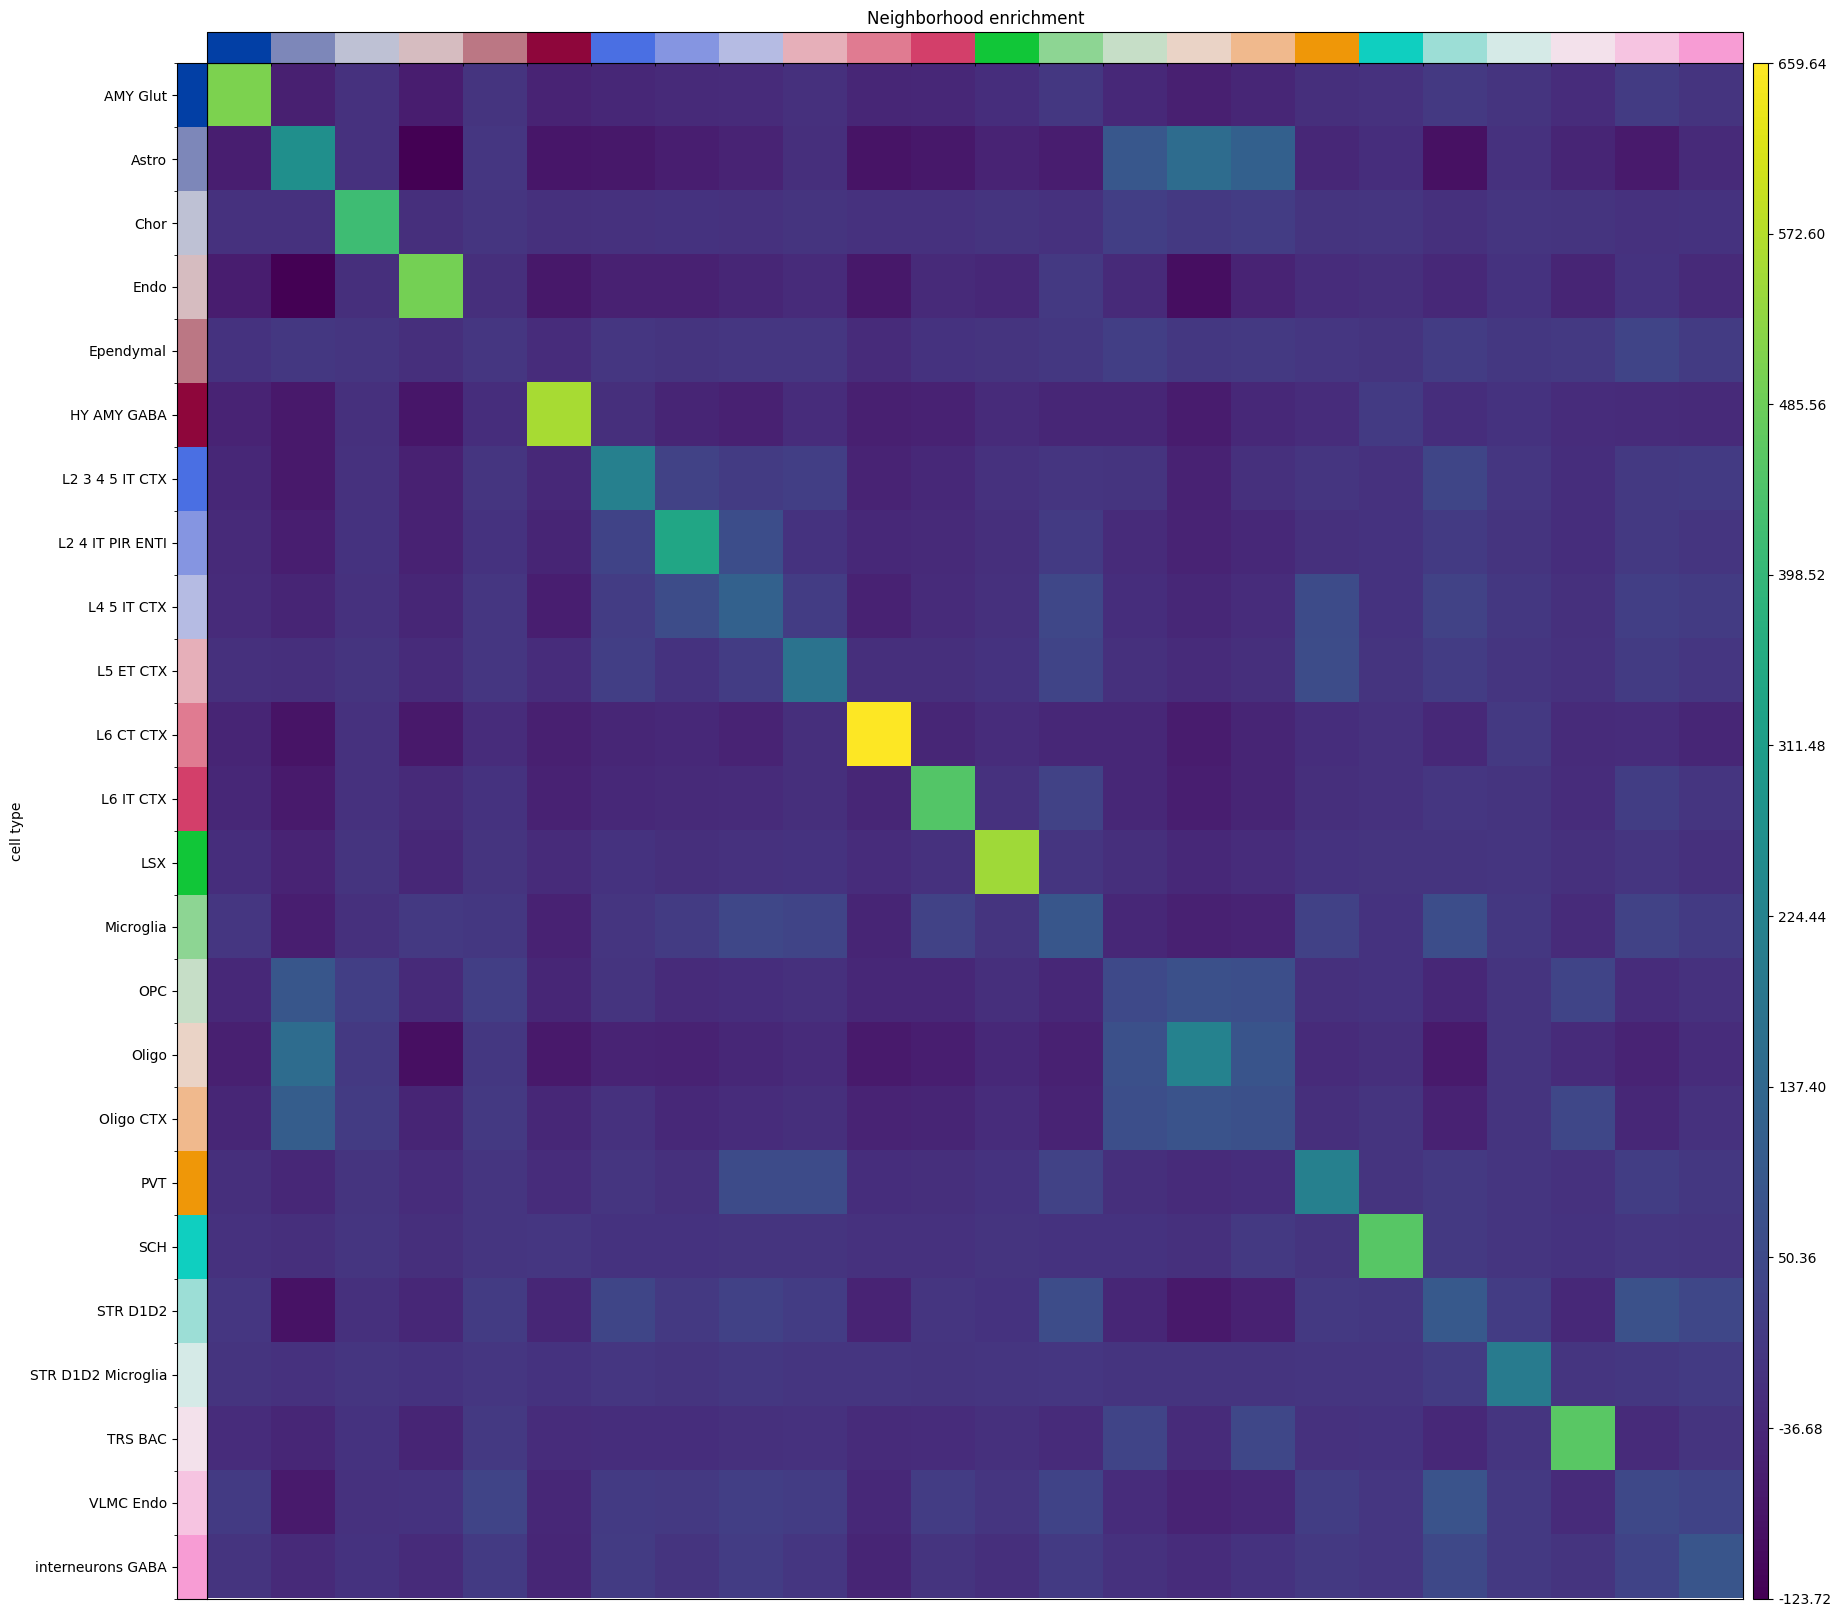

In [112]:
sq.pl.nhood_enrichment(adata, cluster_key="cell type")

# Moran

In [113]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata,
    mode="moran",
    n_perms=100,
    n_jobs=5,
)
adata.uns["moranI"].head(15)

  0%|          | 0/100 [00:00<?, ?/s]

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
Slc17a7_nbr_0,0.976503,0.0,0.000002,0.0,0.009901,0.000005,0.0,0.0,0.009901
Satb2_nbr_0,0.967495,0.0,0.000002,0.0,0.009901,0.000005,0.0,0.0,0.009901
Bhlhe22_nbr_0,0.966582,0.0,0.000002,0.0,0.009901,0.000005,0.0,0.0,0.009901
Prdm8_nbr_0,0.965551,0.0,0.000002,0.0,0.009901,0.000007,0.0,0.0,0.009901
Neurod6_nbr_0,0.965019,0.0,0.000002,0.0,0.009901,0.000007,0.0,0.0,0.009901
Rasl10a_nbr_0,0.963112,0.0,0.000002,0.0,0.009901,0.000006,0.0,0.0,0.009901
2010300C02Rik_nbr_0,0.962461,0.0,0.000002,0.0,0.009901,0.000005,0.0,0.0,0.009901
Fibcd1_nbr_0,0.961821,0.0,0.000002,0.0,0.009901,0.000006,0.0,0.0,0.009901
Slc6a3_nbr_0,0.961268,0.0,0.000002,0.0,0.009901,0.000006,0.0,0.0,0.009901
Slc17a6_nbr_0,0.960573,0.0,0.000002,0.0,0.009901,0.000005,0.0,0.0,0.009901


/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:472: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:650: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(color_source_vector):


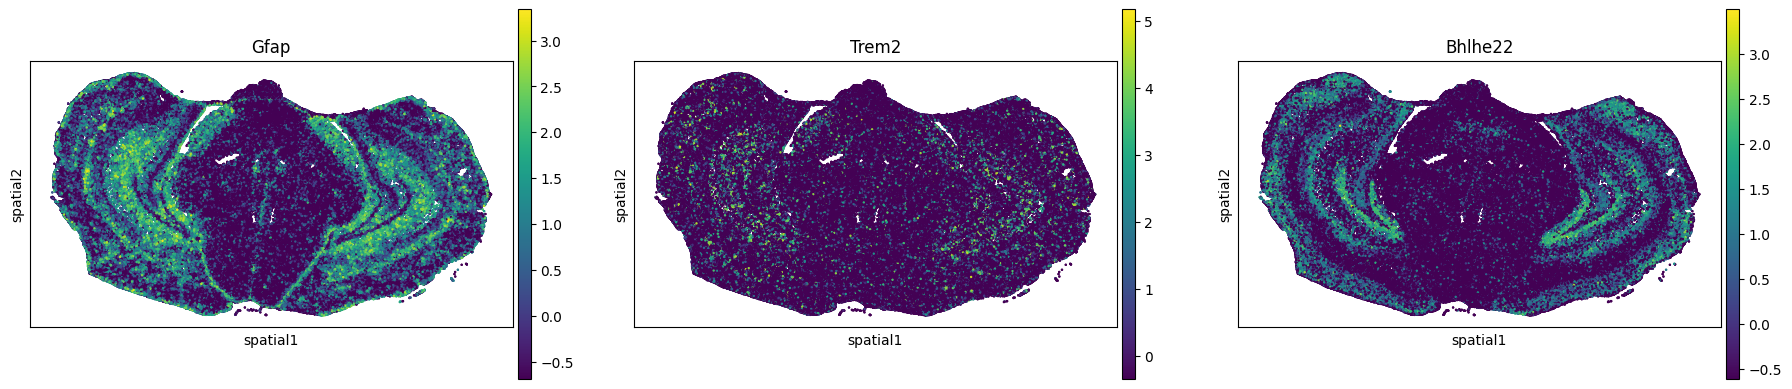

In [115]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Gfap",
        "Trem2",
        "Bhlhe22"
    ],
    shape=None,
    size=2,
    img=False,
)

/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:472: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:650: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(color_source_vector):


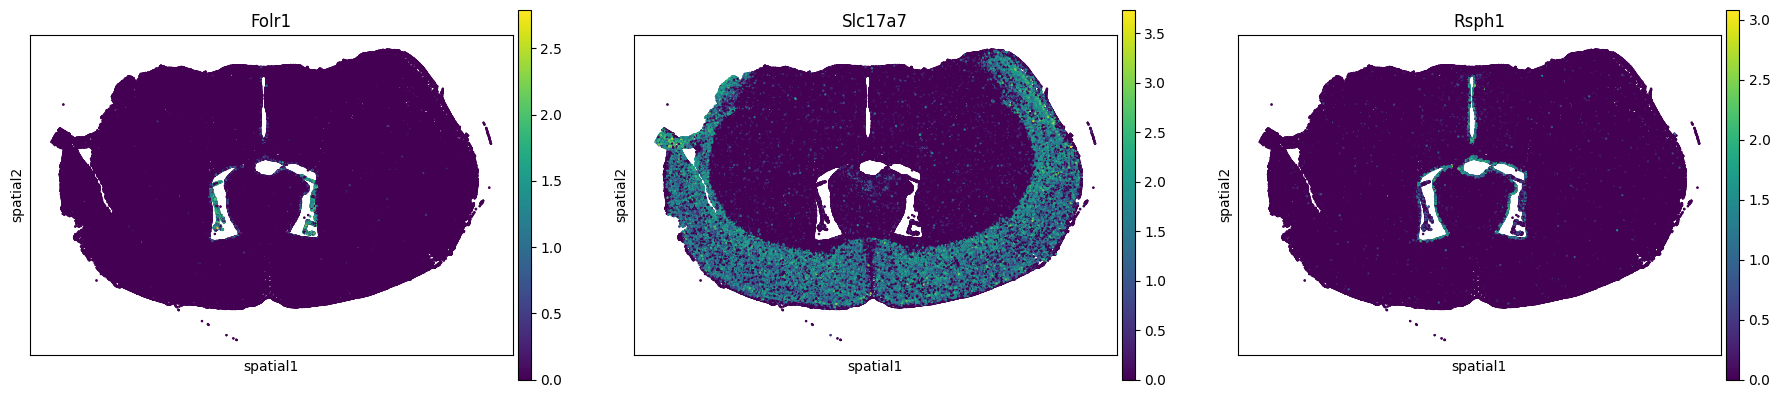

In [96]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Folr1",
        "Slc17a7",
        "Rsph1"
    ],
    shape=None,
    size=2,
    img=False,
)

/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:472: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:650: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(color_source_vector):


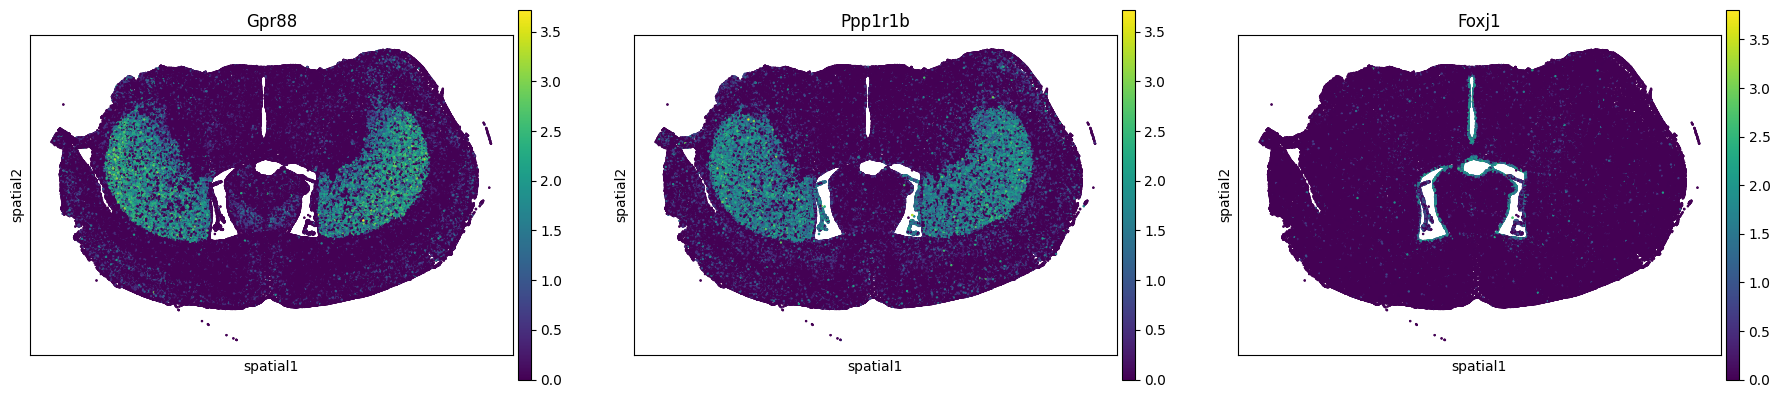

In [97]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Gpr88",
        "Ppp1r1b",
        "Foxj1"
    ],
    shape=None,
    size=2,
    img=False,
)

/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:472: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:650: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(color_source_vector):


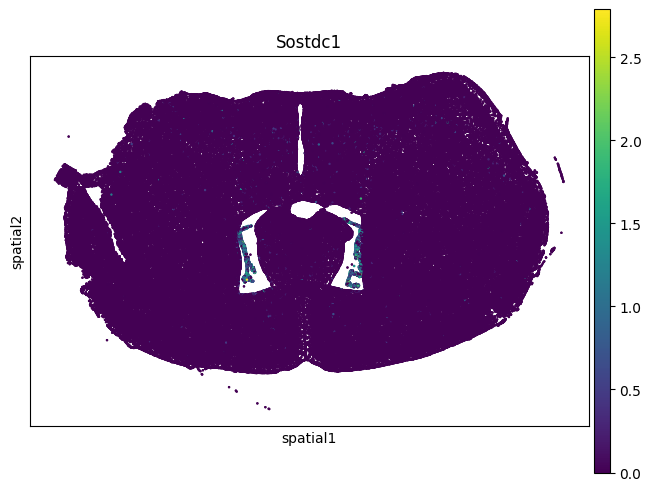

In [103]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Sostdc1",
    ],
    shape=None,
    size=2,
    img=False,
)

In [125]:
grp = adata.obs['run'].unique()
grp

['circa4', 'SD1']
Categories (2, object): ['SD1', 'circa4']

In [18]:
df2 = adata[adata.obs['run'] == 'circa4'].obs.groupby('sample')['region_automap_name'].value_counts()

/tmp/ipykernel_13757/2836504120.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2 = adata[adata.obs['run'] == 'circa4'].obs.groupby('sample')['region_automap_name'].value_counts()


In [19]:
df2.to_csv('temp_region_circa4.csv')